### **Prerequisites for the Lab**

Before the session, ensure you have the environment set up.

1. Install [Ollama](https://ollama.com/) and download a lightweight model: `ollama run llama3` (or `llama3.1` or `mistral`).
2. Install the required Python libraries:

In [27]:
# Step 1: Install system compression tools and dependencies
!sudo apt-get update && sudo apt-get install -y zstd

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:2 http://security.ubuntu.com/ubuntu jammy-security InRelease
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Hit:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease
Hit:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease
Hit:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease
Hit:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:9 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Fetched 3,917 B in 3s (1,437 B/s)
Reading package lists... Done
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
zstd is already the newest version (1.4.8+dfsg-3bu

In [28]:
# Step 2: Download and install the core Ollama environment binary
!curl -fsSL https://ollama.com/install.sh | sh

>>> Cleaning up old version at /usr/local/lib/ollama
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.


In [29]:
import os, subprocess, time

os.environ['OLLAMA_HOST'] = '0.0.0.0:11434'

# Open a log file to catch the output so it doesn't fill the OS pipe
log_file = open('/content/ollama_server.log', 'w')

subprocess.Popen(
    ["ollama", "serve"],
    stdout=log_file,
    stderr=log_file
)

time.sleep(5)

In [30]:
!ollama pull llama3.1

In [31]:
!ollama pull mistral

In [32]:

!ollama pull gemma4:latest

In [33]:
!ollama pull nomic-embed-text

In [34]:
!pip install langgraph langchain-ollama langchain_community chromadb

In [35]:
import uuid
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_core.tools import tool
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_community.vectorstores import Chroma

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import MemorySaver

In [36]:
# 1. INITIALIZE LOCAL MODELS
# Gemma 4 handles native function calling perfectly out of the box.
llm = ChatOllama(model="gemma4:latest", temperature=0)
embeddings = OllamaEmbeddings(model="nomic-embed-text")

In [37]:
# 2. SEED THE LOCAL VECTOR DB (RAG Context)
# For the demo, we seed an in-memory Chroma instance simulating internal company docs.
vector_db = Chroma.from_texts(
    texts=[
        "Project Orion's server deployment blueprint is hosted on internal server cluster IP: 10.240.12.4.",
        "The current lead infrastructure architect for Project Orion is Dr. Aris Thorne.",
    ],
    embedding=embeddings
)
retriever = vector_db.as_retriever(search_kwargs={"k": 1})

In [38]:
# 3. DEFINE THE RAG TOOL
@tool
def query_company_knowledge_base(query: str) -> str:
    """Queries the internal enterprise knowledge base to find specific project information."""
    docs = retriever.invoke(query)
    if not docs:
        return "No specific internal documents matched."
    return "\n".join([doc.page_content for doc in docs])

In [39]:
# Bind the tool directly into Gemma 4's interface engine
tools = [query_company_knowledge_base]
llm_with_tools = llm.bind_tools(tools)

In [40]:
# 4. DEFINE THE GRAPH STATE
class AgentState(TypedDict):
    # add_messages appends new text exchanges into the state natively (Memory)
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [41]:
# 5. DEFINE CORE AGENT NODES
def agent_node(state: AgentState):
    """Evaluates conversation state and decides if a tool execution is required."""
    print("\n--- [Agent Node Active] Evaluating Response Strategy ---")
    system_prompt = SystemMessage(
        content="You are an internal corporate operations assistant. If the user asks about internal systems, "
                "projects, architects, or servers, you MUST use the query_company_knowledge_base tool."
    )
    # Combine system guidance with complete thread history
    conversation = [system_prompt] + state["messages"]
    response = llm_with_tools.invoke(conversation)
    return {"messages": [response]}

In [42]:
def tool_execution_node(state: AgentState):
    """Executes the tool call extracted from the LLM state."""
    print("--- [Tool Node Active] Routing to Local Vector DB ---")
    last_message = state["messages"][-1]

    tool_outputs = []
    for tool_call in last_message.tool_calls:
        if tool_call["name"] == "query_company_knowledge_base":
            # Extract arguments and execute tool function
            result = query_company_knowledge_base.invoke(tool_call["args"])
            # Format output explicitly back to the agent graph
            tool_outputs.append({
                "role": "tool",
                "content": result,
                "tool_call_id": tool_call["id"],
                "name": tool_call["name"]
            })
    return {"messages": tool_outputs}

In [43]:
# 6. CONDITIONAL ROUTING LOGIC
def should_continue(state: AgentState):
    """Inspects the last message to see if a tool execution path is requested."""
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "execute_tool"
    return END

In [44]:
# 7. COMPILE THE ORCHESTRATION GRAPH
workflow = StateGraph(AgentState)

In [45]:
# Append Nodes
workflow.add_node("assistant", agent_node)
workflow.add_node("execute_tool", tool_execution_node)

In [46]:
# Map Edges
workflow.add_edge(START, "assistant")
workflow.add_conditional_edges(
    "assistant",
    should_continue,
    {
        "execute_tool": "execute_tool",
        END: END
    }
)
# Loop tool execution output cleanly back into the assistant node
workflow.add_edge("execute_tool", "assistant")

In [47]:
# Add short-term persistent memory state checkpointing
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

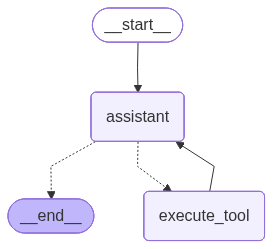

In [48]:
from IPython.display import Image, display

# Generate and display the graph visualization
display(Image(app.get_graph().draw_mermaid_png()))

In [49]:
# Create a unique thread identifier for tracking conversation memory
config = {"configurable": {"thread_id": str(uuid.uuid4())}}

In [50]:
# --- TURN 1: Triggering RAG & Tool Call ---
print("\n=== User Turn 1 ===")
user_msg_1 = HumanMessage(content="Hey! Who is the lead architect for Project Orion?")
for event in app.stream({"messages": [user_msg_1]}, config, stream_mode="values"):
    if event["messages"]:
        print(f"[{event['messages'][-1].type.upper()}]: {event['messages'][-1].content[:120]}...")


=== User Turn 1 ===
[HUMAN]: Hey! Who is the lead architect for Project Orion?...

--- [Agent Node Active] Evaluating Response Strategy ---
[AI]: ...
--- [Tool Node Active] Routing to Local Vector DB ---
[TOOL]: The current lead infrastructure architect for Project Orion is Dr. Aris Thorne....

--- [Agent Node Active] Evaluating Response Strategy ---
[AI]: The current lead infrastructure architect for Project Orion is Dr. Aris Thorne....


In [51]:
# --- TURN 2: Proving Thread Context / Memory Retention ---
print("\n=== User Turn 2 ===")
user_msg_2 = HumanMessage(content="Awesome. What is the deployment IP address for their server?")
for event in app.stream({"messages": [user_msg_2]}, config, stream_mode="values"):
    if event["messages"]:
        print(f"[{event['messages'][-1].type.upper()}]: {event['messages'][-1].content[:120]}...")


=== User Turn 2 ===
[HUMAN]: Awesome. What is the deployment IP address for their server?...

--- [Agent Node Active] Evaluating Response Strategy ---
[AI]: ...
--- [Tool Node Active] Routing to Local Vector DB ---
[TOOL]: Project Orion's server deployment blueprint is hosted on internal server cluster IP: 10.240.12.4....

--- [Agent Node Active] Evaluating Response Strategy ---
[AI]: The deployment IP address for the Project Orion server is **10.240.12.4**....
